Vamos a impelementar dos algoritmos de Aprendizaje por refuerzo: SARSA y Q-learning.

En nuestra impelementacion obteniamos 18 observaciones continuas del estado y sabemos que para estos dos algoritmos necesitamos observaciones dsicretas para no tener una tabla de estados enorme y debemos filtrar esas observaciones:

- Discretizar valores, angulos y sensores
- Discretizar observacion completa 
- Implementar SARSA y Q-learning con esa discretizacion  

## Discretización del estado

El entorno de aparcamiento devuelve una observación continua de dimensión 18, compuesta por posición normalizada, orientación, velocidad, sensores de distancia, distancia al objetivo y errores angulares. ya que sabemos que nuestro salgoritmos no pueden trabajar directamente con valores continuos, se define una función de discretización que transforma la observación continua en una tupla discreta. Esta tupla resume las variables más importantes para la toma de decisiones:

- Posición aproximada del vehículo.
- Distancia al centro de la plaza.
- Ángulo relativo hacia la plaza.
- Error de orientación respecto a la orientación objetivo.
- Lecturas principales de sensores.
- Velocidad del vehículo.

Esta discretización permite aplicar algoritmos tabulares, aunque introduce una pérdida de precisión. Por ejemplo, dos posiciones ligeramente distintas pueden caer en el mismo intervalo discreto. Esta limitación explica que el agente pueda aprender una política válida de aparcamiento, pero no siempre alcance exactamente el centro geométrico de la plaza.

In [5]:
import numpy as np
def discretize_value(value, bins):
    #Devuelve el índice del intervalo en el que cae value.
    return int(np.digitize(value, bins)) #np.digitize devuelve el índice del intervalo al que pertenece value, dado un conjunto de bins

In [6]:
def discretize_sensor(sensor_value):
    """
    Discretiza sensores normalizados:
    0.0 = obstáculo pegado
    1.0 = libre
    Vamos a tener en cuenta 3 estados para cada sensor:
    0 = peligro
    1 = cerca
    2 = libre
    """
    if sensor_value < 0.20:
        return 0
    elif sensor_value < 0.60:
        return 1
    else:
        return 2

In [7]:
def discretize_angle(angle, n_bins=8):
    #Discretiza un ángulo en radianes en n_bins intervalos. El ángulo debe estar en [-pi, pi].
    angle = (angle + np.pi) % (2 * np.pi) - np.pi
    bin_size = 2 * np.pi / n_bins
    return int((angle + np.pi) // bin_size)

In [8]:
def discretize_obs(obs):
    """
    Convierte la observación continua del entorno en un estado discreto
    Observación original:
    [0  x_norm,
     1  y_norm,
     2  cos(theta),
     3  sin(theta),
     4  v_norm,
     5-12 sensores,
     13 distance_to_goal_norm,
     14 cos(angle_to_goal),
     15 sin(angle_to_goal),
     16 cos(orientation_error),
     17 sin(orientation_error)
    ]

    Añadimos x_bin e y_bin para reducir el problema de aliasing:
    dos posiciones distintas no deberían ser necesariamente el mismo estado.
    """

    # Posición normalizada en [-1, 1]
    x_norm = obs[0]
    y_norm = obs[1]

    # Velocidad
    v_norm = obs[4]

    # Sensores principales
    front_sensor = obs[5]
    left_sensor = obs[8]
    right_sensor = obs[9]
    back_sensor = obs[10]

    # Distancia y ángulos
    distance_to_goal = obs[13]
    angle_to_goal = np.arctan2(obs[15], obs[14])
    orientation_error = np.arctan2(obs[17], obs[16])

    # Posición discretizada
    x_bin = discretize_value(
        x_norm,
        bins=[-0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8]
    )

    y_bin = discretize_value(
        y_norm,
        bins=[-0.66, -0.33, 0.0, 0.33, 0.66]
    )

    # Más resolución cerca del objetivo
    dist_bin = discretize_value(
        distance_to_goal,
        bins=[0.03, 0.06, 0.10, 0.15, 0.25, 0.40, 0.60, 0.80]
    )

    # Más bins angulares para distinguir mejor orientación
    angle_goal_bin = discretize_angle(angle_to_goal, n_bins=12)
    orientation_error_bin = discretize_angle(orientation_error, n_bins=12)

    front_bin = discretize_sensor(front_sensor)
    left_bin = discretize_sensor(left_sensor)
    right_bin = discretize_sensor(right_sensor)
    back_bin = discretize_sensor(back_sensor)

    speed_bin = discretize_value(v_norm, bins=[-0.5, -0.05, 0.05, 0.5])

    return (
        x_bin,
        y_bin,
        dist_bin,
        angle_goal_bin,
        orientation_error_bin,
        front_bin,
        left_bin,
        right_bin,
        back_bin,
        speed_bin,
    )

##  Q -LEARNING 

Empezamos con Q-Learning, un método de Aprendizaje por Refuerzo basado en valores. El objetivo del algoritmo es aprender una función Q(s,a), que estima la recompensa acumulada esperada al tomar una acción a en un estado s y seguir posteriormente la mejor política aprendida.

Es un algoritmo off-policy, lo que significa que aprende suponiendo que en el siguiente estado se tomará la mejor acción posible, aunque durante el entrenamiento el agente siga explorando mediante una política epsilon-greedy.

La actualización utilizada es:

Q(s,a) -> Q(s,a) + alpha[r + gamma*max_{a'} Q(s',a') - Q(s,a)]

donde:

- s es el estado actual discretizado.
- a es la acción ejecutada.
- r es la recompensa recibida.
- s' es el nuevo estado tras ejecutar la acción.
- alpha es la tasa de aprendizaje.
- gamma es el factor de descuento.
- max{a'} Q(s',a') representa la mejor acción estimada en el siguiente estado.

En nuestro problema, el entorno de aparcamiento es continuo, por lo que antes de aplicar Q-Learning hemos discretizado la observación. Esta discretización convierte variables como posición, distancia al objetivo, sensores y orientación en intervalos discretos, permitiendo construir una tabla Q.

La política de exploración utilizada es epsilon-greedy: con probabilidad epsilon, el agente elige una acción aleatoria para explorar; con probabilidad 1-epsilon, elige la acción con mayor valor Q aprendido. A medida que avanza el entrenamiento, epsilon disminuye progresivamente para pasar de una fase de exploración a una fase de explotación.

In [9]:
import random
import pickle
from collections import defaultdict

import numpy as np


class QLearningAgent:
    """
    Agente tabular Q-Learning.
    Usa estados discretizados. 
    """

    def __init__(
        self,
        n_actions,
        alpha=0.1,
        gamma=0.95,
        epsilon=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995,):
        self.n_actions = n_actions

        self.alpha = alpha
        self.gamma = gamma

        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        # Q-table:
        # clave: estado discreto, valor: array con valor Q para cada acción
        self.q_table = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float32))

    def select_action(self, state):
        """
        Política epsilon-greedy.
        """
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)

        return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state, done):
        """
        Actualización Q-Learning:

        Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]
        """
        current_q = self.q_table[state][action]

        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])

        self.q_table[state][action] += self.alpha * (target - current_q)

    def decay_epsilon(self):
        """
        Reduce epsilon para pasar poco a poco de explorar a explotar.
        """
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save(self, path):
        """
        Guarda la Q-table en un archivo.
        """
        with open(path, "wb") as f:
            pickle.dump(dict(self.q_table), f)

    def load(self, path):
        """
        Carga una Q-table desde archivo.
        """
        with open(path, "rb") as f:
            data = pickle.load(f)

        self.q_table = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float32))
        self.q_table.update(data)

Entrenamiento q-learning

In [13]:

import pandas as pd
from tqdm import tqdm
import os
import sys

sys.path.append(os.path.abspath(".."))
from envs.continuous_parking_env import ContinuousParkingEnv

def train_qlearning(
    episodes=7000,
    max_steps=300,
    alpha=0.08,
    gamma=0.98,
    epsilon=1.0,
    epsilon_min=0.02,
    epsilon_decay=0.995,
):
    env = ContinuousParkingEnv(render_mode=None)

    agent = QLearningAgent(
        n_actions=env.action_space.n,
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay,
    )

    results = []

    for episode in tqdm(range(episodes), desc="Training Q-Learning"):
        obs, info = env.reset()
        state = discretize_obs(obs)

        total_reward = 0.0
        success = False
        collision = False

        for step in range(max_steps):
            action = agent.select_action(state)

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = discretize_obs(next_obs)

            done = terminated or truncated

            agent.update(
                state=state,
                action=action,
                reward=reward,
                next_state=next_state,
                done=done,
            )

            state = next_state
            total_reward += reward

            if info["is_success"]:
                success = True

            if info["collision"]:
                collision = True

            if done:
                break

        agent.decay_epsilon()

        results.append({
            "episode": episode,
            "reward": total_reward,
            "success": int(success),
            "collision": int(collision),
            "steps": step + 1,
            "epsilon": agent.epsilon,
            "final_distance": info["distance_to_goal"],
        })

    env.close()
    from pathlib import Path

    results_dir = Path(r"C:\Users\laura\OneDrive\Escritorio\TERCERO 2º CUATRI CCDD\AAII\RL\parking_rl\results")
    results_dir.mkdir(parents=True, exist_ok=True)

    df = pd.DataFrame(results)

    results_csv = results_dir / "qlearning_results_v3.csv"
    qtable_path = results_dir / "qlearning_qtable_v3.pkl"

    df.to_csv(results_csv, index=False)
    agent.save(qtable_path)

    print("Entrenamiento terminado.")
    print(f"Resultados guardados en {results_csv}")
    print(f"Q-table guardada en {qtable_path}")

    return agent, df


if __name__ == "__main__":
    train_qlearning()



Training Q-Learning: 100%|██████████| 7000/7000 [2:10:51<00:00,  1.12s/it]  


Entrenamiento terminado.
Resultados guardados en C:\Users\laura\OneDrive\Escritorio\TERCERO 2º CUATRI CCDD\AAII\RL\parking_rl\results\qlearning_results_v3.csv
Q-table guardada en C:\Users\laura\OneDrive\Escritorio\TERCERO 2º CUATRI CCDD\AAII\RL\parking_rl\results\qlearning_qtable_v3.pkl


Step 244 | Acción: 6 (frenar) | Reward: 155.105 | Total: 187.026 | Distancia: 0.342 | Éxito: True | Colisión: False


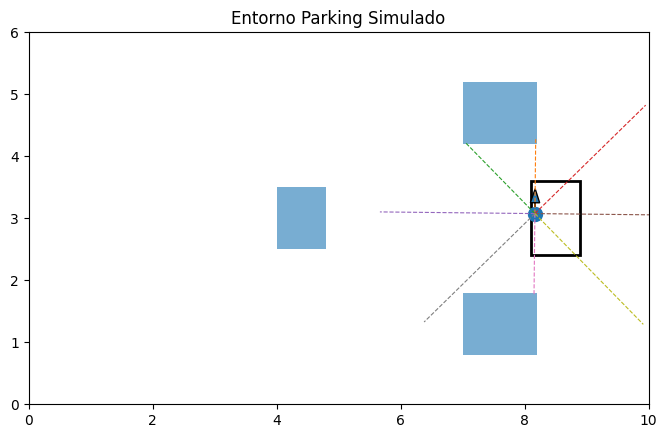

Episodio terminado
Reward total: 187.02614739418425
Info final: {'x': 8.166088171769992, 'y': 3.0756722931449576, 'theta': 1.5600000000000014, 'v': 0.0, 'distance_to_goal': 0.3423791229724884, 'orientation_error': 0.010796326794895172, 'min_sensor_distance': 0.47999998927116394, 'collision': False, 'is_success': True, 'steps': 245}


In [16]:
#cargar tabla para visualizar resultados
import time
from IPython.display import clear_output, display
import sys
from pathlib import Path
from envs.continuous_parking_env import ContinuousParkingEnv

# Si el notebook está dentro de agents/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

env = ContinuousParkingEnv(render_mode="human")

agent = QLearningAgent(n_actions=env.action_space.n)
agent.load("C:\\Users\\laura\\OneDrive\\Escritorio\\TERCERO 2º CUATRI CCDD\\AAII\\RL\\parking_rl\\results\\qlearning_qtable_v2.pkl") 
# Muy importante: sin exploración
agent.epsilon = 0.0

obs, info = env.reset()
state = discretize_obs(obs)

total_reward = 0

action_names = {
    0: "avanzar recto",
    1: "avanzar izquierda",
    2: "avanzar derecha",
    3: "retroceder recto",
    4: "retroceder izquierda",
    5: "retroceder derecha",
    6: "frenar"
}

for step in range(400):
    action = agent.select_action(state)

    next_obs, reward, terminated, truncated, info = env.step(action)
    next_state = discretize_obs(next_obs)

    total_reward += reward
    state = next_state

    clear_output(wait=True)

    print(
        f"Step {step:03d} | "
        f"Acción: {action} ({action_names[action]}) | "
        f"Reward: {reward:.3f} | "
        f"Total: {total_reward:.3f} | "
        f"Distancia: {info['distance_to_goal']:.3f} | "
        f"Éxito: {info['is_success']} | "
        f"Colisión: {info['collision']}"
    )

    env.render()
    display(env.fig)

    time.sleep(0.02)

    if terminated or truncated:
        print("Episodio terminado")
        break

env.close()

print("Reward total:", total_reward)
print("Info final:", info)

## SARSA

(State-Action-Reward-State-Action), es otro método tabular basado en valores. Al igual que Q-Learning, SARSA aprende una función Q(s,a), pero la forma en la que actualiza los valores es diferente.

Es un algoritmo on-policy, es decir, aprende teniendo en cuenta la propia política que está siguiendo durante el entrenamiento. En lugar de actualizar usando la mejor acción posible del siguiente estado, como hace Q-Learning, SARSA actualiza usando la acción real que el agente selecciona en el siguiente estado.

La actualización es:


Q(s,a) -> Q(s,a) + alpha*[r + gamma Q(s',a') - Q(s,a)]

donde:

- s es el estado actual.
- a es la acción tomada.
- r es la recompensa recibida.
- s' es el nuevo estado.
- a' es la siguiente acción seleccionada por la política epsilon-greedy.
- alpha es la tasa de aprendizaje.
- gamma es el factor de descuento.

La diferencia principal con Q-Learning es que SARSA tiene en cuenta la exploración real del agente. Esto puede hacer que aprenda políticas más prudentes en entornos con riesgo, como nuestro caso, donde una mala acción puede provocar una colisión o una maniobra ineficiente.

En este trabajo resulta interesante comparar Q-Learning y SARSA porque ambos usan la misma discretización del entorno, pero aprenden de forma distinta. Q-Learning tiende a ser más optimista porque actualiza con la mejor acción futura estimada, mientras que SARSA puede ser más conservador al considerar la acción que realmente se ejecutará.

In [1]:
class SARSAAgent:
    def __init__(
        self,
        n_actions,
        alpha=0.08,
        gamma=0.98,
        epsilon=1.0,
        epsilon_min=0.02,
        epsilon_decay=0.995,
    ):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float32))

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state, next_action, done):
        current_q = self.q_table[state][action]

        if done:
            target = reward
        else:
            target = reward + self.gamma * self.q_table[next_state][next_action]

        self.q_table[state][action] += self.alpha * (target - current_q)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(dict(self.q_table), f)

    def load(self, path):
        with open(path, "rb") as f:
            data = pickle.load(f)
        self.q_table = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float32))
        self.q_table.update(data)

Se realizó una primera versión del entrenamiento con Q-Learning. Tras observar comportamientos de oscilación y estancamiento, se modificó la función de recompensa y se entrenó una segunda versión. La versión final seleccionada es Q-Learning v3.

v3 está entrenado después de modificar el entorno para corregir justo los problemas que vimos antes: oscilación, estancamiento, mejor recompensa por orientación y bonus por centrado. En el entorno actual tenemos variables como previous_action, best_distance_to_goal y stagnation_steps, que se usan para controlar esos comportamientos raros. Es decir, la recompensa actual ya penaliza oscilaciones, riesgo, colisión y frenadas incorrectas.

In [13]:

import pandas as pd
from tqdm import tqdm
import os
import sys

sys.path.append(os.path.abspath(".."))
from envs.continuous_parking_env import ContinuousParkingEnv

def train_sarsa(
    episodes=7000,
    max_steps=300,
    alpha=0.06,
    gamma=0.98,
    epsilon=1.0,
    epsilon_min=0.02,
    epsilon_decay=0.999,
):
    env = ContinuousParkingEnv(render_mode=None)

    agent = SARSAAgent(
        n_actions=env.action_space.n,
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay,
    )

    results = []

    for episode in tqdm(range(episodes), desc="Training Sarsa"):
        obs, info = env.reset()
        state = discretize_obs(obs)

        total_reward = 0.0
        success = False
        collision = False

        for step in range(max_steps):
            action = agent.select_action(state)

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = discretize_obs(next_obs)

            done = terminated or truncated

            agent.update(
                state=state,
                action=action,
                next_action=agent.select_action(next_state),
                reward=reward,
                next_state=next_state,
                done=done,
            )

            state = next_state
            total_reward += reward

            if info["is_success"]:
                success = True

            if info["collision"]:
                collision = True

            if done:
                break

        agent.decay_epsilon()

        results.append({
            "episode": episode,
            "reward": total_reward,
            "success": int(success),
            "collision": int(collision),
            "steps": step + 1,
            "epsilon": agent.epsilon,
            "final_distance": info["distance_to_goal"],
        })

    env.close()
    from pathlib import Path

    results_dir = Path(r"C:\Users\laura\OneDrive\Escritorio\TERCERO 2º CUATRI CCDD\AAII\RL\parking_rl\results")
    results_dir.mkdir(parents=True, exist_ok=True)

    df = pd.DataFrame(results)

    results_csv = results_dir / "SARSA_v2.csv"
    qtable_path = results_dir / "SARSA_qtable_v2.pkl"

    df.to_csv(results_csv, index=False)
    agent.save(qtable_path)

    print("Entrenamiento terminado.")
    print(f"Resultados guardados en {results_csv}")
    print(f"Q-table guardada en {qtable_path}")

    return agent, df


if __name__ == "__main__":
    train_sarsa()



Training Sarsa: 100%|██████████| 7000/7000 [1:33:32<00:00,  1.25it/s]


Entrenamiento terminado.
Resultados guardados en C:\Users\laura\OneDrive\Escritorio\TERCERO 2º CUATRI CCDD\AAII\RL\parking_rl\results\SARSA_v2.csv
Q-table guardada en C:\Users\laura\OneDrive\Escritorio\TERCERO 2º CUATRI CCDD\AAII\RL\parking_rl\results\SARSA_qtable_v2.pkl


Step 284 | Acción: 6 (frenar) | Reward: 155.096 | Total: 238.287 | Distancia: 0.347 | Éxito: True | Colisión: False


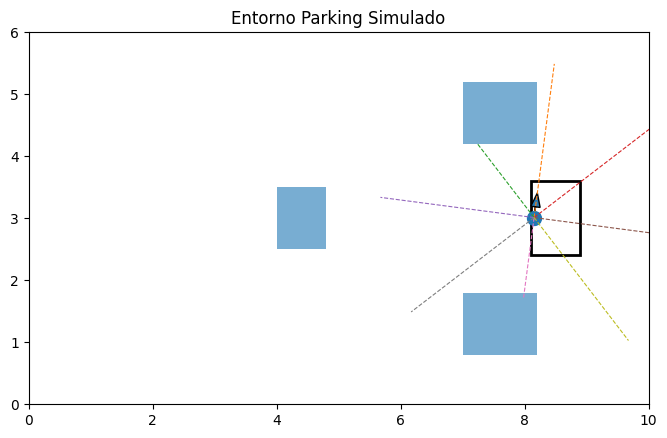

Episodio terminado
Reward total: 238.28745916843815
Info final: {'x': 8.153255170583135, 'y': 3.011335097296382, 'theta': 1.4400000000000013, 'v': 0.0, 'distance_to_goal': 0.34692975878715515, 'orientation_error': 0.13079632679489528, 'min_sensor_distance': 0.5199999809265137, 'collision': False, 'is_success': True, 'steps': 285}


In [17]:
#cargar tabla para visualizar resultados
import time
from IPython.display import clear_output, display
import sys
from pathlib import Path
from envs.continuous_parking_env import ContinuousParkingEnv

# Si el notebook está dentro de agents/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

env = ContinuousParkingEnv(render_mode="human")

agent = SARSAAgent(n_actions=env.action_space.n)
agent.load("C:\\Users\\laura\\OneDrive\\Escritorio\\TERCERO 2º CUATRI CCDD\\AAII\\RL\\parking_rl\\results\\SARSA_qtable_v2.pkl") 
# Muy importante: sin exploración
agent.epsilon = 0.0

obs, info = env.reset()
state = discretize_obs(obs)

total_reward = 0

action_names = {
    0: "avanzar recto",
    1: "avanzar izquierda",
    2: "avanzar derecha",
    3: "retroceder recto",
    4: "retroceder izquierda",
    5: "retroceder derecha",
    6: "frenar"
}

for step in range(400):
    action = agent.select_action(state)

    next_obs, reward, terminated, truncated, info = env.step(action)
    next_state = discretize_obs(next_obs)

    total_reward += reward
    state = next_state

    clear_output(wait=True)

    print(
        f"Step {step:03d} | "
        f"Acción: {action} ({action_names[action]}) | "
        f"Reward: {reward:.3f} | "
        f"Total: {total_reward:.3f} | "
        f"Distancia: {info['distance_to_goal']:.3f} | "
        f"Éxito: {info['is_success']} | "
        f"Colisión: {info['collision']}"
    )

    env.render()
    display(env.fig)

    time.sleep(0.02)

    if terminated or truncated:
        print("Episodio terminado")
        break

env.close()

print("Reward total:", total_reward)
print("Info final:", info)

Podemos observar que en ambos algoritmos toman el mismo camino, sin embargo en el Q-learning podemos ver que hace algunas maniobras un poco más extrañas para entrar en la plaza de aparcamiento pero una vez que entra, entra bien. sin embargo SARSA va mas directo a la plaza sin hacer maniobras tan extrañas pero luego le cuesta meterse entero y comienza a echar un poco para delante y para atrás entonces eso también le penalizaría. 

SARSA tiene bastante mas reward final que seguramente sea porque va bastante más directo a la plaza aunque luego se atasque, además el número de pasos es mas alto en SARSA por eso mismo porque esta bastante tiempo al final sin entrar del todo y el de Q-learning da mas vueltas pero al final entra directo.

Por ello deberíamos decidir que tiene más prioridad para nosotros, que se mueva con mas claridad hacia el aparcamiento o que estando cerca entre directamente. Consideramos que elegir una de estas dos opciones dependería de la utilidad, en nuestro entorno se premia más claramente a SARSA, lo podemos comprobar mirando el reward pero dependeria de varias cosas la eleccion de uno o de otro.

## Hiperparámetros utilizados

Los hiperparámetros controlan cómo aprende el agente durante el entrenamiento. En los algoritmos tabulares implementados se han utilizado los siguientes:

| Hiperparámetro | Valor usado | Significado |
|---|---:|---|
| `episodes` | 7000 | Número total de episodios de entrenamiento |
| `max_steps` | 300 | Número máximo de pasos por episodio |
| `alpha` | 0.08 | Tasa de aprendizaje |
| `gamma` | 0.98 | Factor de descuento |
| `epsilon` | 1.0 | Probabilidad inicial de exploración |
| `epsilon_min` | 0.02 | Valor mínimo de exploración |
| `epsilon_decay` | 0.995 | Factor de decaimiento de epsilon |

La tasa de aprendizaje alpha determina cuánto se actualiza la tabla Q en cada paso. Un valor demasiado alto puede hacer que el aprendizaje sea inestable, mientras que uno demasiado bajo puede ralentizar la convergencia. Se ha utilizado alpha = 0.08 para permitir un aprendizaje progresivo y relativamente estable.

El factor de descuento gamma = 0.98 da bastante importancia a las recompensas futuras. Esto es adecuado para el problema de aparcamiento, ya que algunas acciones pueden no ser beneficiosas de forma inmediata pero sí necesarias para completar correctamente la maniobra.

La política de exploración es epsilon-greedy. Al inicio, epsilon = 1.0, por lo que el agente explora mucho. A medida que avanza el entrenamiento, epsilon disminuye mediante epsilon_decay, permitiendo que el agente explote progresivamente la política aprendida. Se mantiene un mínimo de exploración epsilon_min = 0.02 para evitar que el agente deje completamente de explorar.

Para SARSA hemos modificado a:

- alpha = 0.06: SARSA puede ser más sensible a la exploración, así que una tasa de aprendizaje algo menor puede estabilizar.
- epsilon_decay = 0.999: con 0.995, epsilon baja demasiado rápido. En unos cientos de episodios ya está casi en el mínimo. Para SARSA conviene que explore más tiempo.